# Lab 03: Is There a Planet in Your Light Curve?

**ASTR 457, Fall 2026, posted Thu Sep 17, due Wed Sep 23 by Noon (fork → PR, as always)**

*Why this lab: transit fitting by maximum likelihood is how thousands of planets, including every temperate world around an M dwarf that David Charbonneau will talk about at the Sep 29 colloquium, were actually measured, and the gap between an error bar computed the lazy way and one computed honestly is exactly the gap between a claim that survives referees and one that doesn't.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `t_days`
(time from the start of a ~27-day TESS-style observing sector, 30-minute cadence, with a
~1-day data gap in the middle), `flux_rel` (relative flux, normalized near 1), and
`sigma_flux` (the per-point **white-noise** uncertainty). Your star is a nearby M dwarf
with a candidate transiting super-Earth. The light curve contains: the transit train,
slow instrumental systematics (drifts over days), and, as you will discover, noise
that is not entirely captured by `sigma_flux`. I know the true mid-transit time $t_0$,
period $P$, depth $\delta$, and duration $T$ for your dataset. You don't, you can't look
them up, and your classmates' planets are different from yours.

**How this is graded.** As always: on whether your answers are *right* and your
uncertainties are *honest*. Your reported depth and period are compared to your truth in
units of your own reported uncertainty. Anti-sandbagging cap: your $\sigma_\delta$ may
not exceed 3× a reference uncertainty I compute for your dataset; defensive error bars
lose points just like overconfident ones.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and
document it in Part 4. You may be selected to defend this lab in person (the practice
round was Sep 15; the real ones use the same format).

## The transit model (given)

Use this five-parameter periodic trapezoid, the small-planet limit of Mandel & Agol
(2002), the same model from Tuesday's lecture. The parameters are
$\theta = (t_0, P, \delta, T, F_0)$: mid-transit time of the first transit, period,
depth, total duration, and out-of-transit baseline flux. Ingress and egress each span
20% of the duration.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import scipy
from scipy.interpolate import make_splrep

def transit_model(t, t0, period, depth, duration, baseline, ingress_frac=0.2):
    """Periodic trapezoidal transit train."""
    ph = ((t - t0 + 0.5 * period) % period) - 0.5 * period
    half = duration / 2.
    ing = ingress_frac * duration
    f = np.ones_like(t)
    inside = np.abs(ph) < half
    full = np.abs(ph) < (half - ing)
    f[inside] = 1. - depth * np.clip((half - np.abs(ph[inside])) / ing, 0., 1.)
    f[full] = 1. - depth
    return baseline * f

NETID = 'jonaham2'  # <-- set this
d = np.genfromtxt(f'../../labs/03/data/{NETID}.csv', delimiter=',', names=True, skip_header=1)
t, flux, sigma = d['t_days'], d['flux_rel'], d['sigma_flux']
print(f'{len(t)} points spanning {t[-1]:.1f} days; stated sigma = {sigma[0]*1e3:.2f} ppt')

1263 points spanning 27.4 days; stated sigma = 1.59 ppt


## Part 1: Find the planet (20%)

1. Plot the raw light curve. Identify the slow systematic trend and the transits.
2. **Detrend** the light curve. Be deliberate: state your method (median filter, spline,
   polynomial per segment, your choice), your smoothing scale, and *why that scale
   can't eat your transits*. Plot raw, trend, and detrended flux.
3. From the detrended curve, read off by eye: approximate $t_0$, $P$, depth, duration:
   your initial guesses for Part 2.
4. Compare the out-of-transit scatter of your detrended flux to the stated `sigma_flux`.
   Are they consistent? Say what you conclude (a sentence is fine, and you'll need this
   observation in Parts 2 and 3).

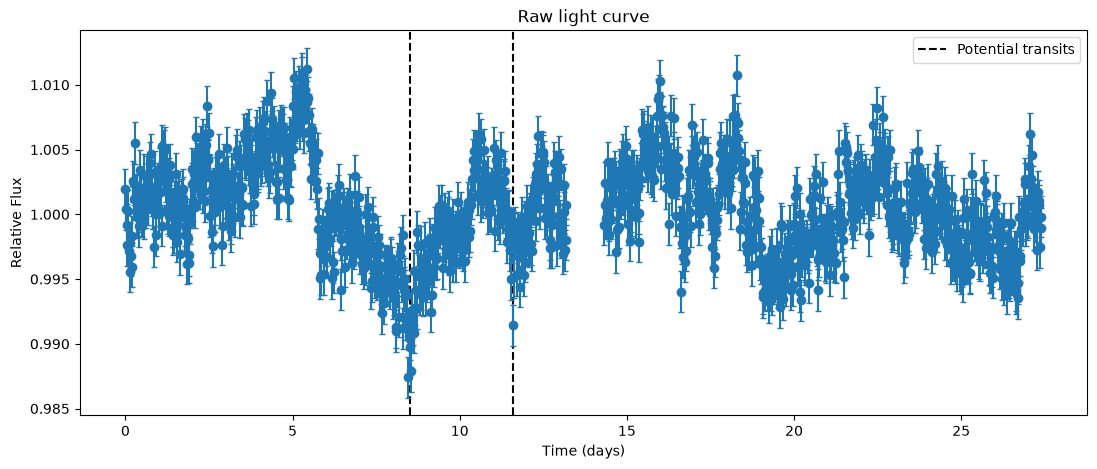

In [2]:
# Part 1: your work here

fig, ax = plt.subplots(figsize=(13, 5))
plt.axvline(8.5, ls='--', c='black', label='Potential transits')
plt.axvline(11.6, ls='--', c='black')
plt.errorbar(t, flux, sigma, fmt='o', capsize=2)
plt.xlabel('Time (days)')
plt.ylabel(r'Relative Flux')
plt.title('Raw light curve')
plt.legend()
plt.show()

In the above data it's clear that there is some systematic trend in the light curve, manifesting itself in apparent sinusoidal tracks across the entire observation period, increasing and decreasing the relative flux without the presence of a transit. The transits themselves are much shorter dips in the light curve of the star, occuring with relatively regular periodicity. Potential transits can be seen around 8.5 and 11.6 days.

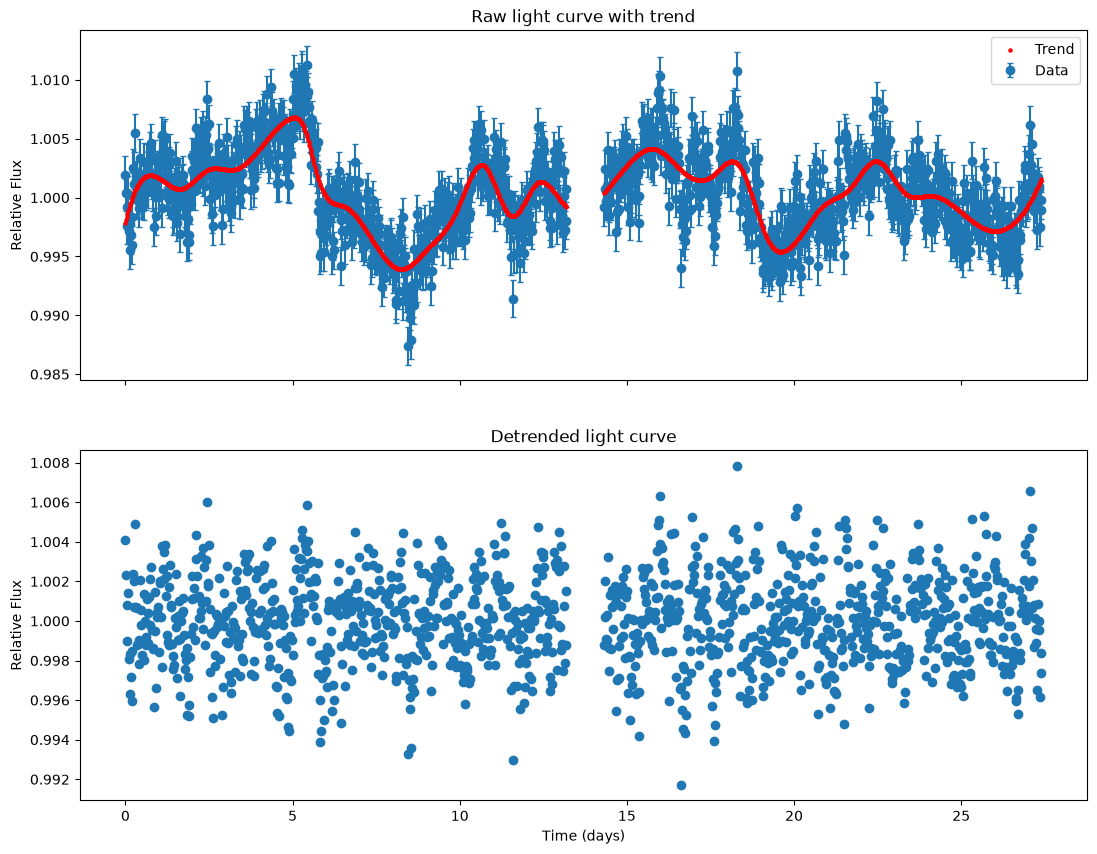

In [3]:
# detrending the data using a median filter

spline = make_splrep(t, flux, w=1/sigma, s=2500)
trend = spline(t)
detrended = flux/trend

fig, ax = plt.subplots(2, 1, figsize=(13, 10), sharex=True)

ax[0].errorbar(t, flux, sigma, fmt='o', capsize=2, label='Data', zorder=0)
ax[0].scatter(t, trend, s=5, c='r', label='Trend', zorder=1)
ax[0].set_ylabel('Relative Flux')
ax[0].set_title('Raw light curve with trend')
ax[0].legend()

# ax[2].errorbar(t, flux-trend, sigma, fmt='o', capsize=2)
ax[1].scatter(t, detrended)
ax[1].set_xlabel('Time (days)')
ax[1].set_ylabel(r'Relative Flux')
ax[1].set_title('Detrended light curve')
plt.show()

To detrend the raw light curve data, I chose to implement a spline technique that would be able to pick out the trend in the raw data so it can easily be subtracted out to reveal the exolpanet transits. I chose the spline technique, because it would be able to smoothly follow the trend of the data through a least-squares fit model to the data, given some input parameter, s. This least squares fitting would grant it robustness against outliers and short transits, as they wouldn't affect the data in the same manner as the overall trend in the light curve would. For the spline fitting I chose to use a fitting parameter value of 2500, as it was what granted me the most optimal fit to the data upon inspection. The documentation for the spline model recommends that if the data points are weighted with a weight equal to 1/sigma (which our data is), then a good value for s might lie somewhere in the range (m+sqrt(2*m), m-sqrt(2*m)), where m is the number of data points. This would give me an s value somewhere in the 1200s, though, which proved to be too small and overfit the data, thus erasing the transits. Because of this, I increased it manually until I found a value of s that properly fit the trend of the data without any overfitting of the data. This new model can't erase the transits, because they occur on a much smaller timescale than the spline model is able to recognize.

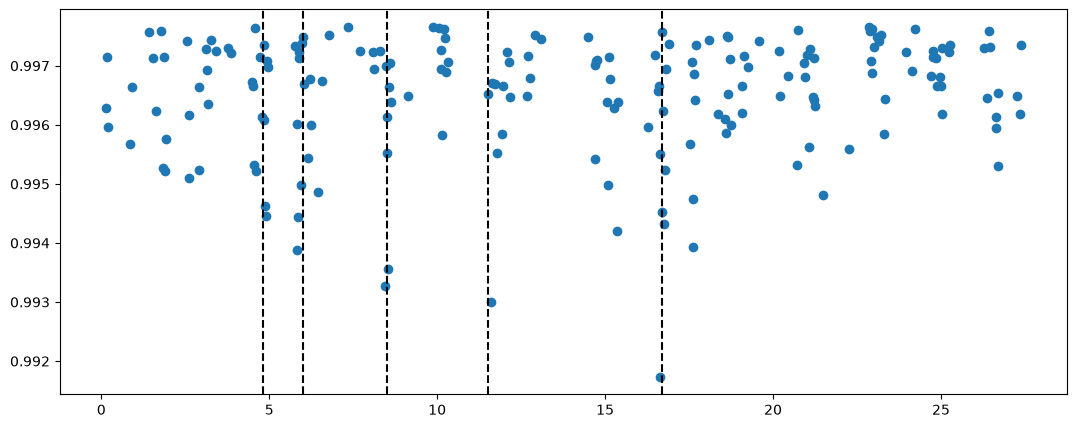

In [97]:
# visually exploring light curve

mask = detrended < np.quantile(detrended, 0.15) # masking out the really high flux values to easily locate transits

fig, ax = plt.subplots(figsize=(13, 5))
ax.scatter(t[mask], detrended[mask])
ax.axvline(16.7, ls='--', c='black', label='Potential transit')
ax.axvline(8.5, ls='--', c='black')
ax.axvline(11.5, ls='--', c='black')
ax.axvline(6, ls='--', c='black')
ax.axvline(4.8, ls='--', c='black')
plt.show()

#### Exploring transits

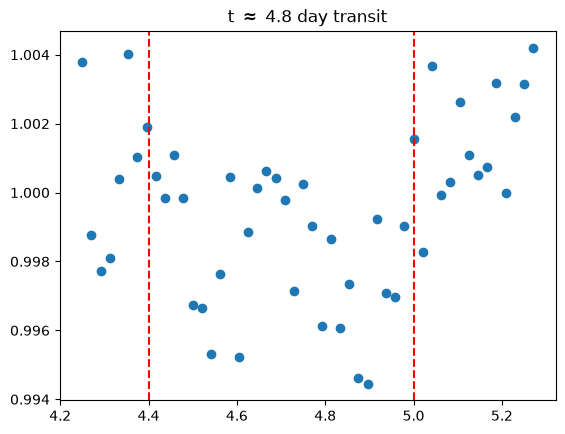

In [100]:
t0_guess = 4.8

index = np.where(np.isclose(t, t0_guess, rtol=0.01))[0][0]

plt.scatter(t[index-25:index+25], detrended[index-25:index+25])
plt.axvline(4.4, c='red', ls='--')
plt.axvline(5, c='red', ls='--')
plt.title(r't $\approx$ 4.8 day transit')
plt.show()

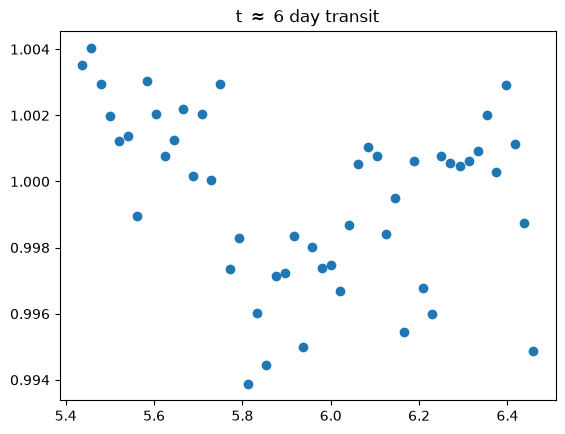

In [102]:
t0_guess = 6

index = np.where(np.isclose(t, t0_guess, rtol=0.01))[0][0]

plt.scatter(t[index-25:index+25], detrended[index-25:index+25])
plt.title(r't $\approx$ 6 day transit')
plt.show()

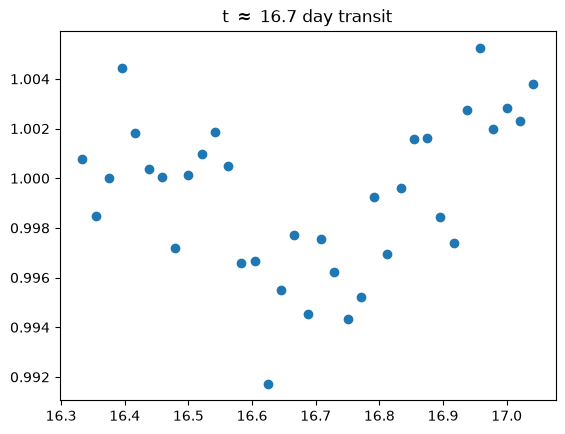

In [85]:
t0_guess = 16.7

index = np.where(np.isclose(t, t0_guess, rtol=0.01))[0][0]

plt.scatter(t[index-10:index+25], detrended[index-10:index+25])
plt.title(r't $\approx$ 16.7 day transit')
plt.show()

In [114]:
scatter = detrended - 1
print(f'estimated scatter of {np.mean(np.abs(scatter))}')

estimated scatter of 0.0017847628394762056


**ANSWERS (initial guesses + scatter check):**

Through cursory observation, my initial guesses for the start, period, depth, and duration of the transits are $t_0 \approx 4.8$ days, $P_0 \approx 3$ days, depth $\approx 0.005$, and duration $\approx 0.5$ days. The estimated scatter on the data is 0.00178, which is much lower than the stated `sigma_flux` value.

## Part 2: The measurement you'd publish (40%)

1. Write the Gaussian log-likelihood for the transit model and maximize it
   (`scipy.optimize.minimize`; Nelder-Mead first, as in lecture). Fit all five
   parameters. Plot the phase-folded data with your best-fit model, and the residuals.
2. Estimate uncertainties **two ways**:
   - from the curvature of the log-likelihood at the maximum (the inverse Hessian,
     lecture method), and
   - by **bootstrap**, and think about *what* you resample: if you resample individual
     points, what are you assuming about the noise? A block bootstrap (resample
     contiguous chunks of residuals, e.g. 1-day blocks) makes a different assumption.
     Do both point-wise and block versions and compare.
3. The three uncertainty estimates for the depth will not all agree. Explain the pattern
   using your Part 1 scatter observation. Which noise property do the Hessian and the
   point-wise bootstrap both assume that your residuals violate? Demonstrate that
   violation with a plot or a number (hint: bin your residuals in ~5-hour bins and
   compare the binned scatter to what independent noise predicts).
4. **Commit to final answers**: $\delta \pm \sigma_\delta$, $P \pm \sigma_P$,
   $t_0 \pm \sigma_{t_0}$, and justify which uncertainty estimate you adopted.

In [ ]:
# Part 2: your work here

# code stolen from lab 2

def neg_log_likelihood(theta, x):
    b = 2.5
    r0 = 4
    x0,fbg = theta
    model = 1/(np.sqrt(2*np.pi*sigma))*np.exp(-0.5*())
    return -np.sum(np.log(model))

def hessian(func, theta, x, eps=1e-5):
    n = len(theta)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            di = np.zeros(n)
            dj = np.zeros(n)
            di[i] = eps
            dj[j] = eps

            H[i,j] = (func(theta + di + dj, x) - func(theta + di - dj, x) - func(theta - di + dj, x) + func(theta - di - dj, x))/(4*eps**2)
    return H

sc_x0 = np.mean(clipped_data)

theta0 = [sc_x0, sc_fb]
result = minimize(neg_log_likelihood, theta0, args=(data), method='Nelder-Mead')
mm_x0,mm_fbg = result.x

H = hessian(neg_log_likelihood, result.x, data)

cov = np.linalg.inv(H)

mm_x0_sig  = np.sqrt(cov[0,0])
mm_fbg_sig = np.sqrt(cov[1,1])

**FINAL ANSWER:** $\delta = $ ___ $\pm$ ___ ppt, $P = $ ___ $\pm$ ___ d, $t_0 = $ ___ $\pm$ ___ d

**Which uncertainty and why (a short paragraph):**

*your answer goes here*

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis
of this exact problem, produced by an AI assistant. It runs top to bottom without
errors, the phase-folded plot looks professional, and the prose is fluent. It is also
wrong, in at least **three** distinct, substantive ways (cosmetic nitpicks don't
count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset. Show, with a number or a
   plot, what the error does to the inference. "This is bad practice" is not a
   demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

You've done this once before, on Lab 01. Notice how much faster you are at it now.
That speed is the skill this course is building.

**REFEREE REPORT:**

*Flaw 1:*

*Flaw 2:*

*Flaw 3:*

In [ ]:
# Part 3: demonstrations here


## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use, for what, what did they get wrong, and how did
   you catch it? Honesty is graded; "I didn't use any" is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers. For each check: what would failure have looked like? (One check you should
   seriously consider: simulate a light curve with parameters you chose, run your whole
   pipeline on it, and see whether you recover what you put in.)

**AI-USE APPENDIX:**

*your answer goes here*

**VERIFICATION PLAN:**

*your answer goes here*